1. Setup and Data Loading

Loaded 100,836 ratings across 610 users and 9724 movies.
Train: 80,668  |  Test: 20,168  |  Global mean: 3.5026


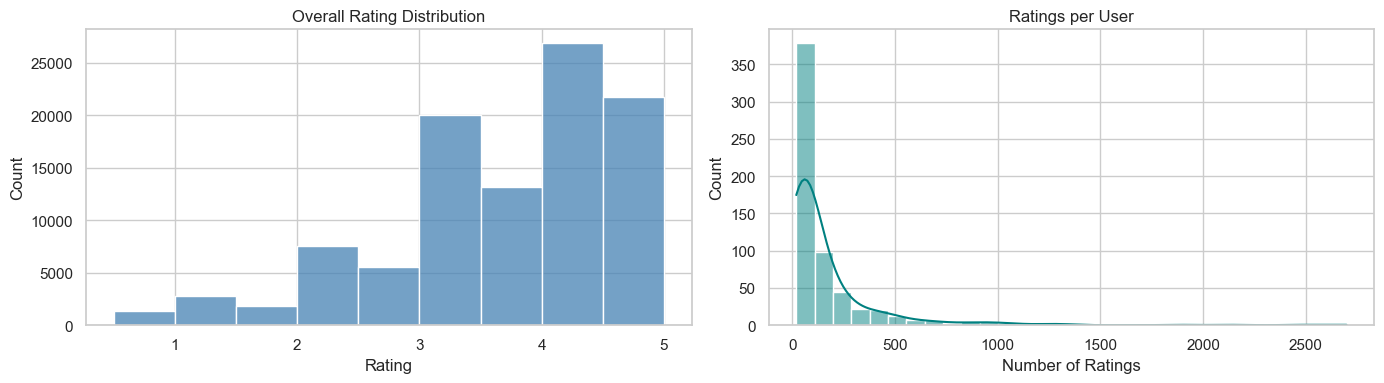

In [13]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
%matplotlib inline

DATA_DIR   = Path('../../dataset')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')

train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

global_mean = float(train_df['rating'].mean())
print(f'Loaded {len(ratings):,} ratings across {ratings["userId"].nunique()} users and {ratings["movieId"].nunique()} movies.')
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}  |  Global mean: {global_mean:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ratings['rating'], bins=9, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Rating')

ratings_per_user = ratings.groupby('userId').size()
sns.histplot(ratings_per_user, bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Number of Ratings')
plt.tight_layout()
plt.show()

2. Matrix Construction & Sparsity

Matrix : 610 users x 8983 movies
Sparsity: 98.53%  (80,668 rated / 5,479,630 possible)


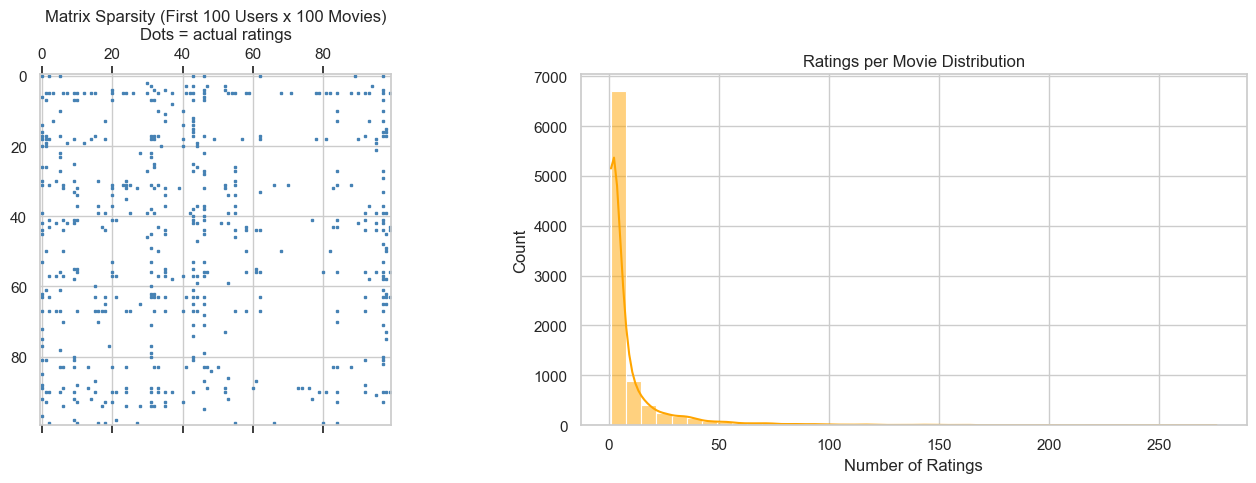

In [14]:
matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)
matrix_vals = matrix.values.astype(float)

user_index  = {uid: i for i, uid in enumerate(matrix.index)}
movie_index = {mid: i for i, mid in enumerate(matrix.columns)}

total_cells  = matrix_vals.shape[0] * matrix_vals.shape[1]
filled_cells = (matrix_vals != 0).sum()
sparsity     = 1 - filled_cells / total_cells
print(f'Matrix : {matrix_vals.shape[0]} users x {matrix_vals.shape[1]} movies')
print(f'Sparsity: {sparsity:.2%}  ({filled_cells:,} rated / {total_cells:,} possible)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].spy(matrix.iloc[:100, :100], markersize=1.5, color='steelblue')
axes[0].set_title('Matrix Sparsity (First 100 Users x 100 Movies)\nDots = actual ratings')

ratings_per_movie = train_df.groupby('movieId').size()
sns.histplot(ratings_per_movie, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Ratings per Movie Distribution')
axes[1].set_xlabel('Number of Ratings')
plt.tight_layout()
plt.show()

3. SVD (Singular Value Decomposition)

Training SVD...
SVD  RMSE=0.9478  MAE=0.7350


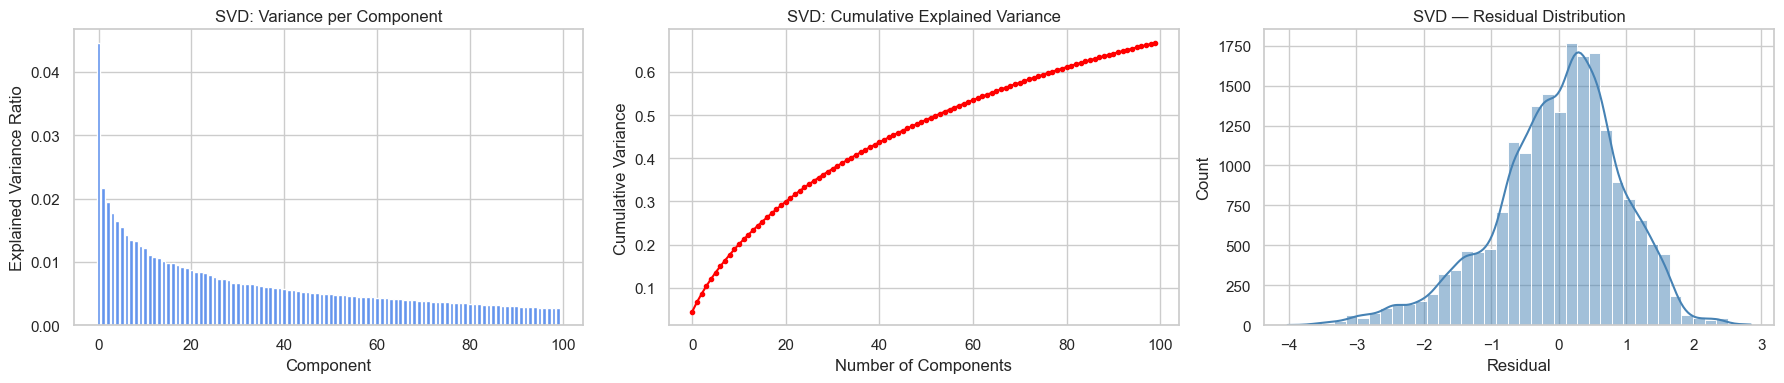

In [15]:
print('Training SVD...')
counts    = (matrix_vals != 0).sum(1)
row_means = np.where(counts > 0, matrix_vals.sum(1) / np.maximum(counts, 1), global_mean)

matrix_centred = matrix_vals.copy()
for i in range(matrix_centred.shape[0]):
    mask = matrix_centred[i] != 0
    matrix_centred[i, mask] -= row_means[i]

svd     = TruncatedSVD(n_components=100, random_state=42)
U_sigma = svd.fit_transform(matrix_centred)
Vt      = svd.components_

# Evaluate SVD on test set
svd_preds_list = []
for _, row in test_df.iterrows():
    uid, mid = row['userId'], row['movieId']
    if uid in user_index and mid in movie_index:
        u_i = user_index[uid]
        m_i = movie_index[mid]
        pred = np.dot(U_sigma[u_i], Vt[:, m_i]) + row_means[u_i]
    else:
        pred = global_mean
    svd_preds_list.append(pred)

svd_preds = np.clip(svd_preds_list, 0.5, 5.0)
svd_rmse  = np.sqrt(mean_squared_error(test_df['rating'], svd_preds))
svd_mae   = mean_absolute_error(test_df['rating'], svd_preds)
print(f'SVD  RMSE={svd_rmse:.4f}  MAE={svd_mae:.4f}')

# Explained variance + residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(range(len(svd.explained_variance_ratio_)), svd.explained_variance_ratio_, color='cornflowerblue')
axes[0].set_title('SVD: Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(np.cumsum(svd.explained_variance_ratio_), color='red', marker='o', markersize=3)
axes[1].set_title('SVD: Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')

residuals = test_df['rating'].values - svd_preds
sns.histplot(residuals, bins=40, kde=True, color='steelblue', ax=axes[2])
axes[2].set_title('SVD — Residual Distribution')
axes[2].set_xlabel('Residual')
plt.tight_layout()
plt.show()

4. KNN (K-Nearest Neighbors)

Training KNN...
KNN  RMSE=0.9989  MAE=0.7686


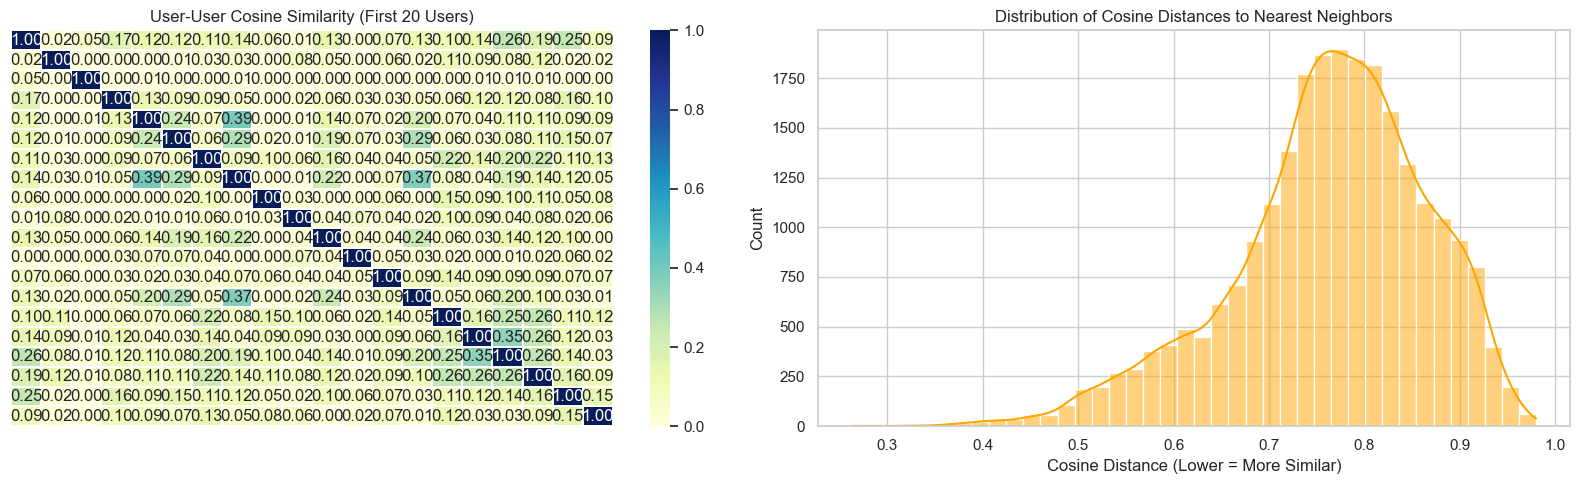

In [16]:
print('Training KNN...')
knn = NearestNeighbors(n_neighbors=41, metric='cosine', algorithm='brute')
knn.fit(matrix_vals)

# Evaluate KNN on test set (weighted average of neighbors)
knn_distances, knn_indices = knn.kneighbors(matrix_vals)

knn_preds_list = []
for _, row in test_df.iterrows():
    uid, mid = row['userId'], row['movieId']
    if uid in user_index and mid in movie_index:
        u_i = user_index[uid]
        m_i = movie_index[mid]
        neighbor_ids   = knn_indices[u_i][1:]   # exclude self
        neighbor_dists = knn_distances[u_i][1:]
        neighbor_rats  = matrix_vals[neighbor_ids, m_i]
        rated_mask     = neighbor_rats != 0
        if rated_mask.sum() > 0:
            sims = 1 - neighbor_dists[rated_mask]
            pred = np.average(neighbor_rats[rated_mask], weights=np.maximum(sims, 1e-6))
        else:
            pred = global_mean
    else:
        pred = global_mean
    knn_preds_list.append(pred)

knn_preds = np.clip(knn_preds_list, 0.5, 5.0)
knn_rmse  = np.sqrt(mean_squared_error(test_df['rating'], knn_preds))
knn_mae   = mean_absolute_error(test_df['rating'], knn_preds)
print(f'KNN  RMSE={knn_rmse:.4f}  MAE={knn_mae:.4f}')

# User-user similarity heatmap + distance distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sim_matrix = cosine_similarity(matrix_vals[:20], matrix_vals[:20])
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0],
            xticklabels=False, yticklabels=False, linewidths=0.3)
axes[0].set_title('User-User Cosine Similarity (First 20 Users)')

sns.histplot(knn_distances[:, 1:].flatten(), bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribution of Cosine Distances to Nearest Neighbors')
axes[1].set_xlabel('Cosine Distance (Lower = More Similar)')
plt.tight_layout()
plt.show()

5. XGBoost

Training XGBoost...
XGBoost  RMSE=0.8839  MAE=0.6721


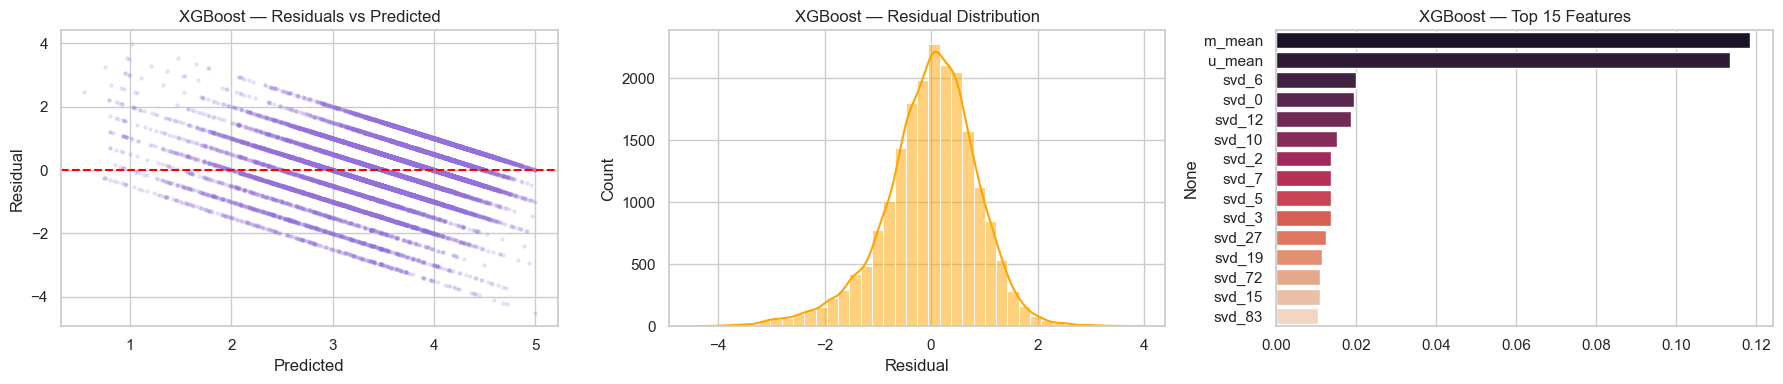

In [17]:
print('Training XGBoost...')
user_stats  = train_df.groupby('userId')['rating'].agg(user_mean='mean', user_count='count')
movie_stats = train_df.groupby('movieId')['rating'].agg(movie_mean='mean', movie_count='count')

u_idx_arr = np.array([user_index[uid] for uid in train_df['userId']])
X_train_xgb = np.column_stack([
    train_df['userId'].map(user_stats['user_mean']).fillna(global_mean),
    train_df['userId'].map(user_stats['user_count']).fillna(0),
    train_df['movieId'].map(movie_stats['movie_mean']).fillna(global_mean),
    train_df['movieId'].map(movie_stats['movie_count']).fillna(0),
    U_sigma[u_idx_arr]
])
y_train_xgb = train_df['rating'].values

valid_mask  = test_df['userId'].isin(user_index)
test_valid  = test_df[valid_mask].reset_index(drop=True)
u_idx_test  = np.array([user_index[uid] for uid in test_valid['userId']])
X_test_xgb  = np.column_stack([
    test_valid['userId'].map(user_stats['user_mean']).fillna(global_mean),
    test_valid['userId'].map(user_stats['user_count']).fillna(0),
    test_valid['movieId'].map(movie_stats['movie_mean']).fillna(global_mean),
    test_valid['movieId'].map(movie_stats['movie_count']).fillna(0),
    U_sigma[u_idx_test]
])

xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0)
xgb.fit(X_train_xgb, y_train_xgb)
xgb_preds = np.clip(xgb.predict(X_test_xgb), 0.5, 5.0)

xgb_rmse = np.sqrt(mean_squared_error(test_valid['rating'], xgb_preds))
xgb_mae  = mean_absolute_error(test_valid['rating'], xgb_preds)
print(f'XGBoost  RMSE={xgb_rmse:.4f}  MAE={xgb_mae:.4f}')

# Residuals + feature importance
residuals = test_valid['rating'].values - xgb_preds
feat_names = ['u_mean', 'u_count', 'm_mean', 'm_count'] + [f'svd_{i}' for i in range(100)]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].scatter(xgb_preds, residuals, alpha=0.15, s=5, color='mediumpurple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('XGBoost — Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('XGBoost — Residual Distribution')
axes[1].set_xlabel('Residual')

imp = pd.Series(xgb.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
sns.barplot(x=imp.values, y=imp.index, palette='rocket', ax=axes[2])
axes[2].set_title('XGBoost — Top 15 Features')
plt.tight_layout()
plt.show()

6. Model Comparison

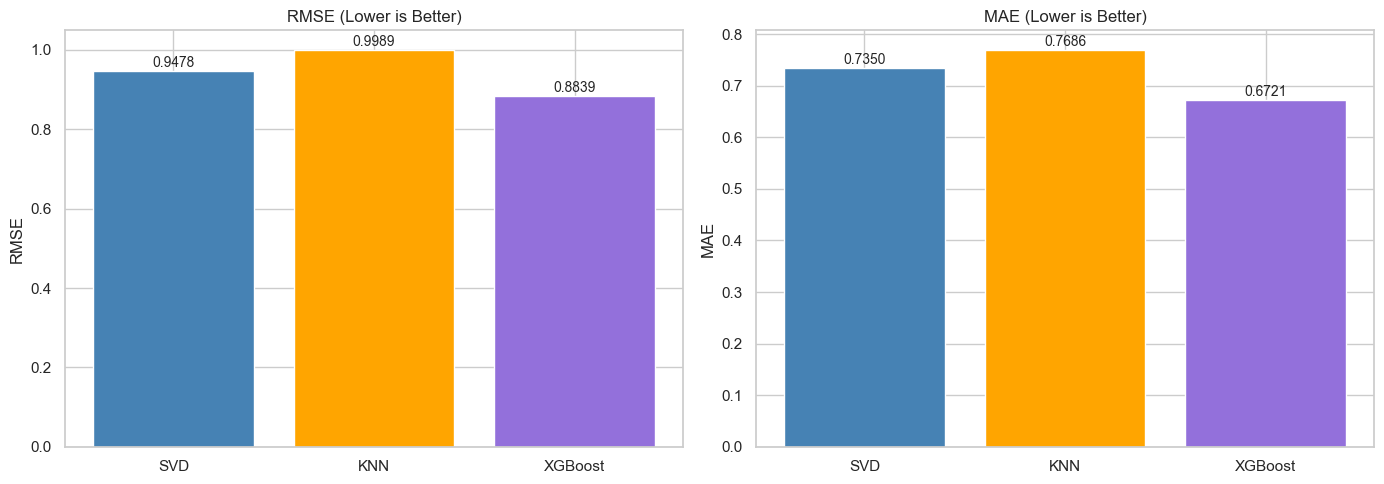

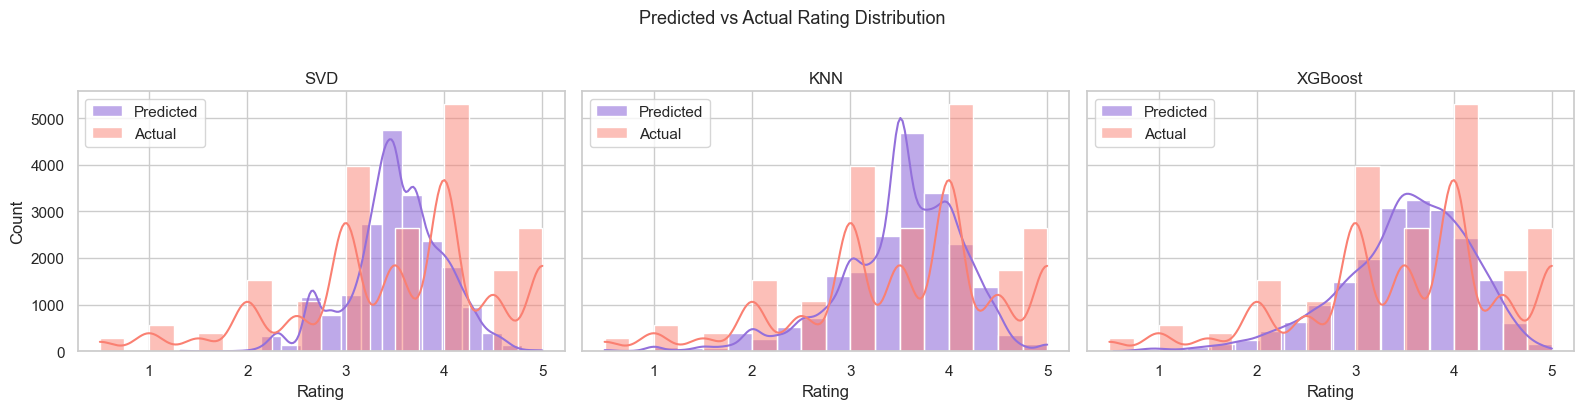

,Model,Type,Primary Signal,RMSE,MAE
0,SVD,Latent Factors,Hidden patterns in ratings,0.9478,0.7350
1,KNN,Neighborhood,Peer similarity,0.9989,0.7686
2,XGBoost,Gradient Boosting,User/movie bias + latent,0.8839,0.6721



Best model: XGBoost (RMSE = 0.8839)


In [18]:
# Use test_valid subset for fair comparison (XGBoost requires known users)
svd_preds_valid  = np.array(svd_preds_list)[valid_mask.values]
knn_preds_valid  = np.array(knn_preds_list)[valid_mask.values]

models_map = {
    'SVD':     svd_preds_valid,
    'KNN':     knn_preds_valid,
    'XGBoost': xgb_preds,
}

perf_df = pd.DataFrame([
    {
        'Model': name,
        'RMSE':  np.sqrt(mean_squared_error(test_valid['rating'], p)),
        'MAE':   mean_absolute_error(test_valid['rating'], p),
    }
    for name, p in models_map.items()
]).set_index('Model')

colors = ['steelblue', 'orange', 'mediumpurple']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(perf_df.index, perf_df[metric], color=colors)
    for bar, val in zip(bars, perf_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{metric} (Lower is Better)')
    ax.set_ylabel(metric)
plt.tight_layout()
plt.show()

# Predicted vs actual distribution overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, preds) in zip(axes, models_map.items()):
    sns.histplot(preds,                    bins=18, kde=True, color='mediumpurple', alpha=0.6, label='Predicted', ax=ax)
    sns.histplot(test_valid['rating'].values, bins=18, kde=True, color='salmon',  alpha=0.5, label='Actual',    ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Rating')
    ax.legend()
plt.suptitle('Predicted vs Actual Rating Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model':          ['SVD', 'KNN', 'XGBoost'],
    'Type':           ['Latent Factors', 'Neighborhood', 'Gradient Boosting'],
    'Primary Signal': ['Hidden patterns in ratings', 'Peer similarity', 'User/movie bias + latent'],
    'RMSE':           perf_df['RMSE'].values.round(4),
    'MAE':            perf_df['MAE'].values.round(4),
})
display(summary)
best = perf_df['RMSE'].idxmin()
print(f'\nBest model: {best} (RMSE = {perf_df.loc[best, "RMSE"]:.4f})')